# Sprint 1 - Configuração e versionamento

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [2]:
# Caminho base do projeto (pasta onde está este notebook)
base_dir = os.getcwd()

# Para utilizar com Databricks localmente
# base_dir = '/Workspace/Users/leonardobadell@protonmail.com/MIni-projeto-avaliativo-modulo-2'


path_def_front = os.path.join(base_dir, 'def_front')
path_ok_front = os.path.join(base_dir, 'ok_front')

# Listar todos os arquivos de imagem de cada pasta
imagens_def = [os.path.join(path_def_front, f) for f in os.listdir(path_def_front) 
               if f.endswith(('.jpg', '.jpeg', '.png'))]
imagens_ok = [os.path.join(path_ok_front, f) for f in os.listdir(path_ok_front) 
              if f.endswith(('.jpg', '.jpeg', '.png'))]

# Criar DataFrame com Pandas
df_imagens = pd.DataFrame({
    'caminho': imagens_def + imagens_ok,
    'classe': ['def_front'] * len(imagens_def) + ['ok_front'] * len(imagens_ok)
})

# Criar label numérica usando np.where: 1 = defeito, 0 = ok
df_imagens['label'] = np.where(df_imagens['classe'] == 'def_front', 0, 1)


print(f"Total de imagens carregadas: {len(df_imagens)}")
print(f"\nDistribuição de classes:")
print(df_imagens['classe'].value_counts())
print(f"\nPrimeiras 5 linhas do dataset:")
display(df_imagens.head())

Total de imagens carregadas: 1300

Distribuição de classes:
classe
def_front    781
ok_front     519
Name: count, dtype: int64

Primeiras 5 linhas do dataset:


,caminho,classe,label
0,c:\Users\leonardo.badell\Mini-projeto-avaliati...,def_front,0
1,c:\Users\leonardo.badell\Mini-projeto-avaliati...,def_front,0
2,c:\Users\leonardo.badell\Mini-projeto-avaliati...,def_front,0
3,c:\Users\leonardo.badell\Mini-projeto-avaliati...,def_front,0
4,c:\Users\leonardo.badell\Mini-projeto-avaliati...,def_front,0


# Sprint 2 - Análise exploratória clássica (OpenCV)

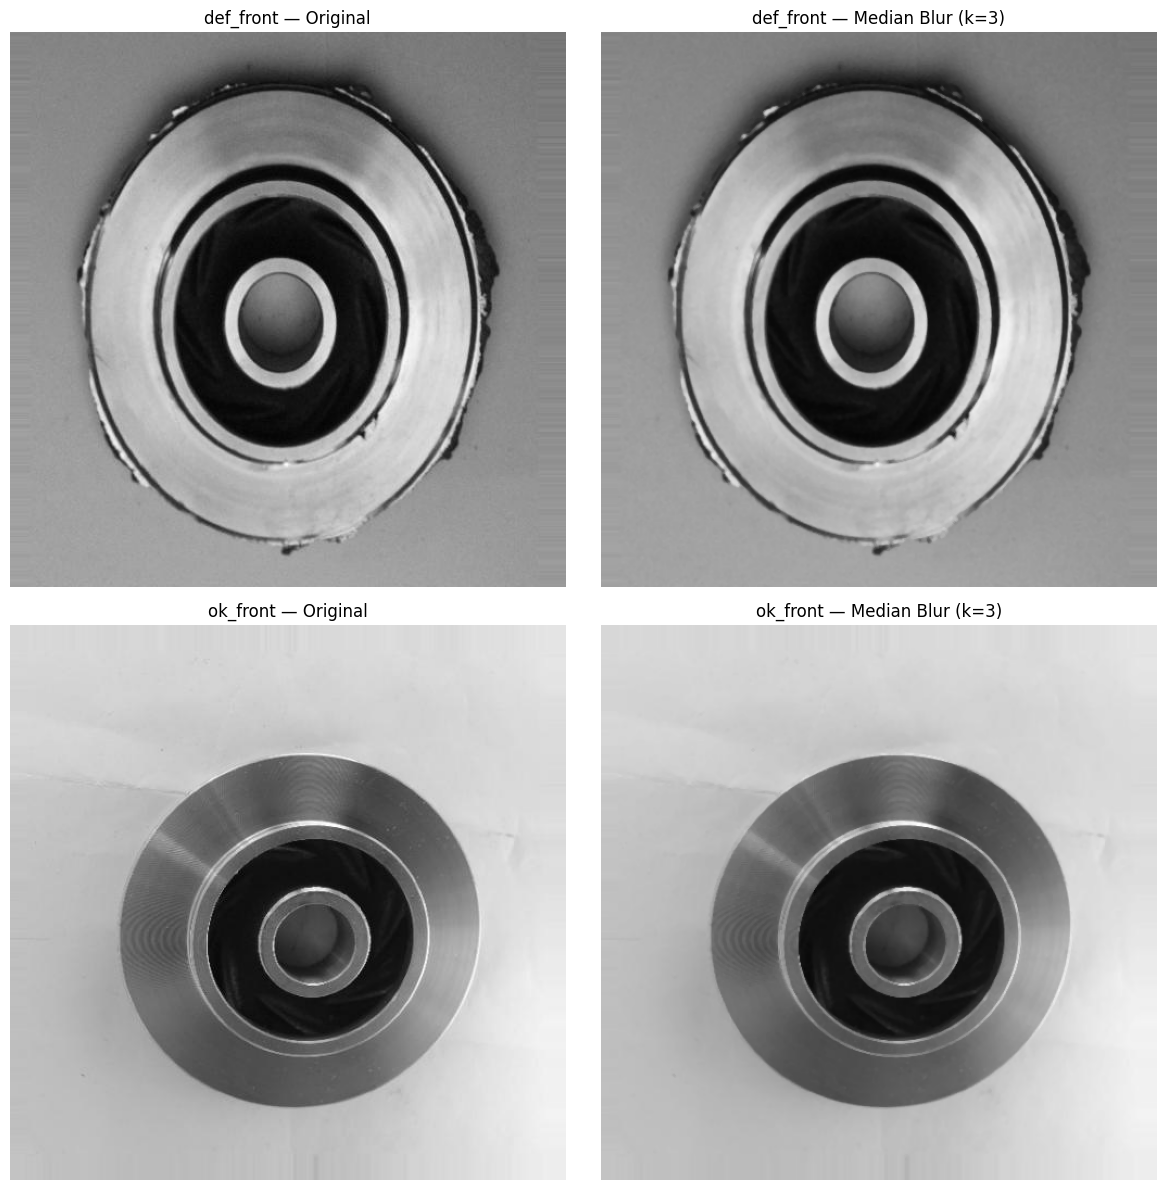

In [3]:
# Utilizando OpenCV para leitura e processamento de imagens
img_def_front = cv2.imread(imagens_def[0])
img_ok_front = cv2.imread(imagens_ok[0])

def aplicar_median_blur(img, k=3):
    img_u8 = img.astype(np.uint8)
    return cv2.medianBlur(img_u8, k)

# Aplicação de filtro de desfoque mediano (Median Blur)
img_def_blur = aplicar_median_blur(img_def_front)
img_ok_blur = aplicar_median_blur(img_ok_front)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img_def_front, cmap='gray')
axes[0, 0].set_title('def_front — Original')
axes[0, 1].imshow(img_def_blur, cmap='gray')
axes[0, 1].set_title('def_front — Median Blur (k=3)')

axes[1, 0].imshow(img_ok_front, cmap='gray')
axes[1, 0].set_title('ok_front — Original')
axes[1, 1].imshow(img_ok_blur, cmap='gray')
axes[1, 1].set_title('ok_front — Median Blur (k=3)')

# Plotagem das imagens com e sem filtro de desfoque mediano
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

def_front — média: 131.58 | desvio padrão: 55.93
ok_front  — média: 167.15 | desvio padrão: 62.90
Teste KS (def_front vs ok_front): estatística=0.4598, p-valor=0.0000


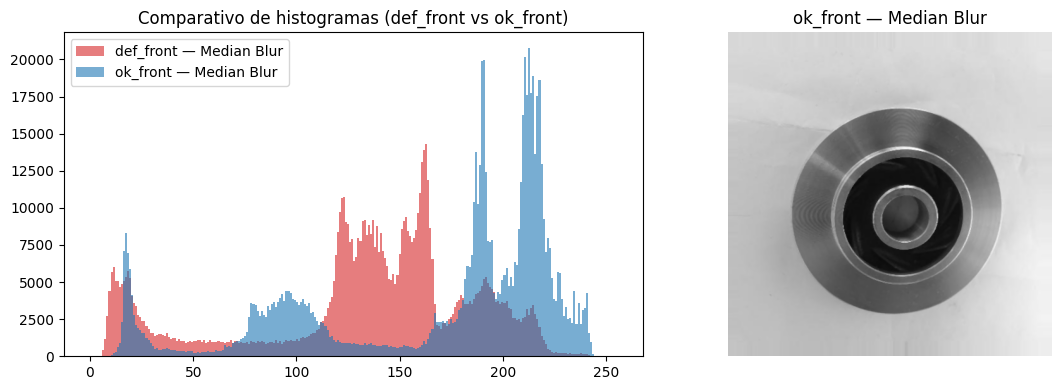

In [4]:
# --- Comparativo estatístico e histogramas: def_front vs ok_front (Median Blur) ---
media_def, desvio_def = img_def_blur.mean(), img_def_blur.std()
media_ok, desvio_ok = img_ok_blur.mean(), img_ok_blur.std()
estatistica_ks, p_valor = stats.ks_2samp(img_def_blur.ravel(), img_ok_blur.ravel())

print(f"def_front — média: {media_def:.2f} | desvio padrão: {desvio_def:.2f}")
print(f"ok_front  — média: {media_ok:.2f} | desvio padrão: {desvio_ok:.2f}")
print(f"Teste KS (def_front vs ok_front): estatística={estatistica_ks:.4f}, p-valor={p_valor:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_def_blur.ravel(), bins=256, range=(0, 255), color='tab:red', alpha=0.6, label='def_front — Median Blur')
axes[0].hist(img_ok_blur.ravel(), bins=256, range=(0, 255), color='tab:blue', alpha=0.6, label='ok_front — Median Blur')
axes[0].set_title('Comparativo de histogramas (def_front vs ok_front)')
axes[0].legend()

axes[1].imshow(img_def_blur, cmap='gray')
axes[1].set_title('def_front — Median Blur')
axes[1].axis('off')

# Plotagem da imagem ok_front com filtro de desfoque mediano
axes[1].imshow(img_ok_blur, cmap='gray')
axes[1].set_title('ok_front — Median Blur')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Sprint 3 - Destaque de características

,classe,limiar_otsu,area_branca_%,borda_media,borda_desvio
0,def_front,95.0,79.97,4.30,11.04
1,ok_front,140.0,71.15,2.15,7.73


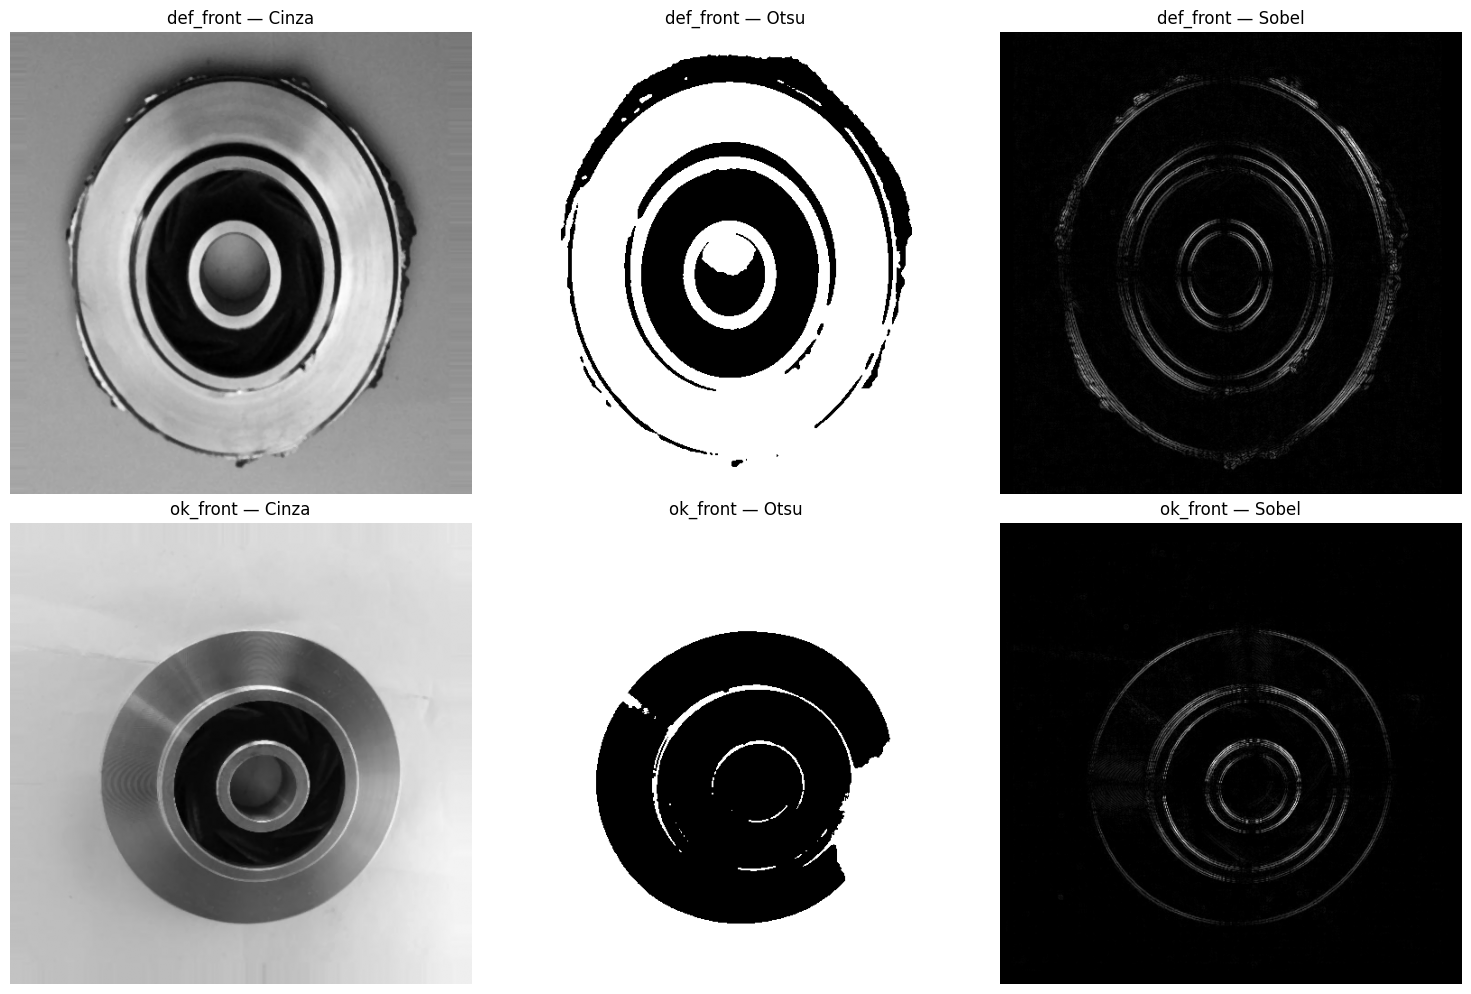

In [5]:
gray_def = cv2.cvtColor(img_def_blur, cv2.COLOR_BGR2GRAY)
gray_ok = cv2.cvtColor(img_ok_blur, cv2.COLOR_BGR2GRAY)

# A. THRESHOLDING (Otsu): separa a peça do fundo escolhendo o limiar automaticamente
limiar_def, thresh_def = cv2.threshold(gray_def, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
limiar_ok, thresh_ok = cv2.threshold(gray_ok, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# B. SOBEL: destaca apenas os contornos, o mesmo princípio que uma CNN aprende sozinha
sobel_def = cv2.convertScaleAbs(cv2.Sobel(gray_def, cv2.CV_64F, 1, 1, ksize=3))
sobel_ok = cv2.convertScaleAbs(cv2.Sobel(gray_ok, cv2.CV_64F, 1, 1, ksize=3))

# C. COMPARATIVO estatístico com pandas
df_features = pd.DataFrame({
    'classe': ['def_front', 'ok_front'],
    'limiar_otsu': [limiar_def, limiar_ok],
    'area_branca_%': [(thresh_def > 0).mean() * 100, (thresh_ok > 0).mean() * 100],
    'borda_media': [sobel_def.mean(), sobel_ok.mean()],
    'borda_desvio': [sobel_def.std(), sobel_ok.std()]
})
display(df_features.round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(gray_def, cmap='gray')
axes[0, 0].set_title('def_front — Cinza')
axes[0, 1].imshow(thresh_def, cmap='gray')
axes[0, 1].set_title('def_front — Otsu')
axes[0, 2].imshow(sobel_def, cmap='gray')
axes[0, 2].set_title('def_front — Sobel')
axes[1, 0].imshow(gray_ok, cmap='gray')
axes[1, 0].set_title('ok_front — Cinza')
axes[1, 1].imshow(thresh_ok, cmap='gray')
axes[1, 1].set_title('ok_front — Otsu')
axes[1, 2].imshow(sobel_ok, cmap='gray')
axes[1, 2].set_title('ok_front — Sobel')

# Desligar os eixos para todas as subplots
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Sprint 4 - Ingestão de dados e augmentation (Keras)

In [6]:

IMG_SIZE = 300
BATCH_SIZE = 32
SEED = 123

# Divisão estratificada
df_train, df_val = train_test_split(
    df_imagens,
    test_size=0.20,
    random_state=SEED,
    stratify=df_imagens["classe"]
)

# Organizar índices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

class_names = ["def_front", "ok_front"]


# Conferência da distribuição
df_distribuicao = (
    df_train["classe"]
    .value_counts()
    .rename("treino")
    .to_frame()
    .merge(
        df_val["classe"]
        .value_counts()
        .rename("validacao")
        .to_frame(),
        left_index=True,
        right_index=True
    )
)

df_distribuicao["treino_%"] = (
    df_distribuicao["treino"]
    / df_distribuicao["treino"].sum()
    * 100
).round(2)

df_distribuicao["validacao_%"] = (
    df_distribuicao["validacao"]
    / df_distribuicao["validacao"].sum()
    * 100
).round(2)

display(df_distribuicao)


# Função para carregar as imagens
def carregar_imagem(caminho, label):

    imagem = tf.io.read_file(caminho)

    imagem = tf.io.decode_image(
        imagem,
        channels=3,
        expand_animations=False
    )

    imagem = tf.image.resize(
        imagem,
        [IMG_SIZE, IMG_SIZE]
    )

    imagem.set_shape(
        [IMG_SIZE, IMG_SIZE, 3]
    )

    return imagem, tf.cast(label, tf.float32)


# Dataset de treinamento
train_ds = tf.data.Dataset.from_tensor_slices((
    df_train["caminho"].to_numpy(),
    df_train["label"].to_numpy()
))

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(df_train),
        seed=SEED
    )
    .map(
        carregar_imagem,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Dataset de validação
val_ds = tf.data.Dataset.from_tensor_slices((
    df_val["caminho"].to_numpy(),
    df_val["label"].to_numpy()
))

val_ds = (
    val_ds
    .map(
        carregar_imagem,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


,treino,validacao,treino_%,validacao_%
classe,,,,
def_front,625,156,60.1,60.0
ok_front,415,104,39.9,40.0


In [7]:
# Aplicando augmentation nos dados
data_augmentation = keras.Sequential([

    layers.RandomRotation(
        0.10,
        fill_mode="constant",
        fill_value=255
    ),

    layers.RandomZoom(
        0.15,
        fill_mode="constant",
        fill_value=255
    ),

    layers.RandomBrightness(0.2),

    layers.RandomContrast(0.2),

    layers.RandomFlip("horizontal")
])

plt.show()

# Sprint 5 - A arquitetura CNN e treinamento

In [8]:
# Definição do modelo de rede neural convolucional (CNN)
model = keras.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    data_augmentation,

    layers.Rescaling(1./255), layers.Conv2D(16, 3, padding="same", activation="relu"),
    
    layers.MaxPooling2D(), layers.Conv2D(32, 3, padding="same", activation="relu"),

    layers.MaxPooling2D(), layers.Conv2D(64, 3, padding="same", activation="relu"),

    layers.MaxPooling2D(),

    layers.Flatten(), 
    layers.Dropout(0.2),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,859,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,884,001 (171.22 MB)

 Trainable params: 44,884,001 (171.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compilação do modelo com adam
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# Definição do callback de early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

In [11]:
# Definição do número de épocas de treinamento
EPOCHS = 80

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 431ms/step - accuracy: 0.5702 - loss: 1.3142 - val_accuracy: 0.6000 - val_loss: 0.6335
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 432ms/step - accuracy: 0.6240 - loss: 0.6390 - val_accuracy: 0.7154 - val_loss: 0.5921
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 429ms/step - accuracy: 0.7077 - loss: 0.5839 - val_accuracy: 0.7077 - val_loss: 0.5533
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 423ms/step - accuracy: 0.6885 - loss: 0.5831 - val_accuracy: 0.7462 - val_loss: 0.5170
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 431ms/step - accuracy: 0.7173 - loss: 0.5507 - val_accuracy: 0.7577 - val_loss: 0.4830
Epoch 6/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 428ms/step - accuracy: 0.7375 - loss: 0.5163 - val_accuracy: 0.8423 - val_loss: 0.4509
Epoch 7/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 477ms/step - accuracy: 0.7490 - loss: 0.5040 - val_accuracy: 0.8308 - val_loss: 0.4331
Epoch 8/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 467ms/step - accuracy: 0.7721 - loss: 0.4767 - val_accu

# Sprint 6 - Auditoria e gravação

1. Curvas de treinamento e validação


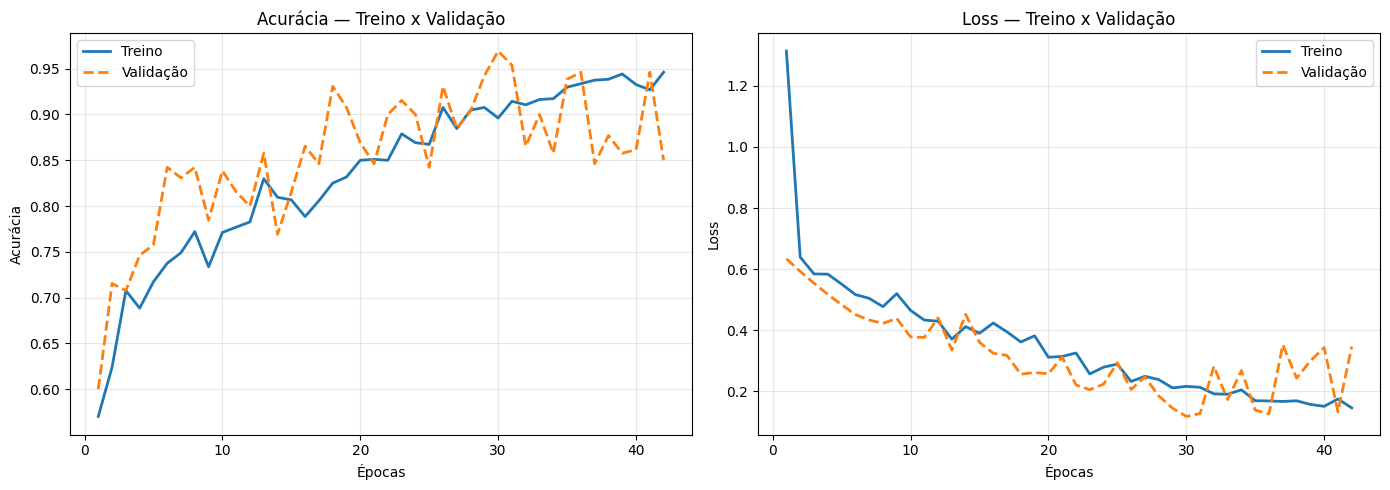

In [12]:

print("1. Curvas de treinamento e validação")

epochs_range = range(
    1,
    len(history.history["accuracy"]) + 1
)

plt.figure(figsize=(14, 5))


# Acurácia
plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    history.history["accuracy"],
    label="Treino",
    linewidth=2
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    label="Validação",
    linewidth=2,
    linestyle="--"
)

plt.title("Acurácia — Treino x Validação")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(alpha=0.3)


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    history.history["loss"],
    label="Treino",
    linewidth=2
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    label="Validação",
    linewidth=2,
    linestyle="--"
)

plt.title("Loss — Treino x Validação")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:

# Predições no conjunto de validação

rotulos_reais = []
predicoes = []

for imagens, labels in val_ds:

    probabilidades = model.predict(
        imagens,
        verbose=0
    ).flatten()

    classes_previstas = (
        probabilidades >= 0.5
    ).astype(int)

    rotulos_reais.extend(
        labels.numpy().flatten().astype(int)
    )

    predicoes.extend(
        classes_previstas
    )

rotulos_reais = np.array(rotulos_reais)
predicoes = np.array(predicoes)


2. Matriz de confusão


Text(0.5, 25.581597222222214, 'Classe prevista')

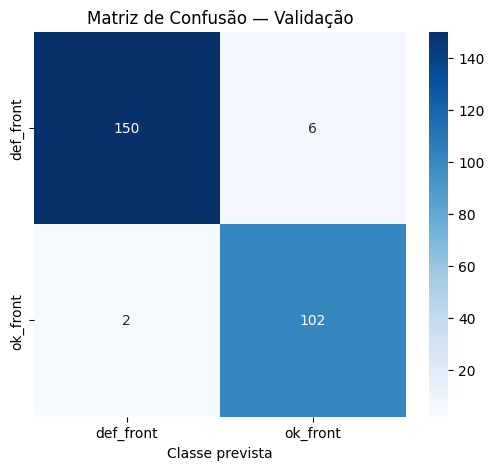

In [14]:

# Matriz de confusão

print("\n2. Matriz de confusão")

matriz = confusion_matrix(
    rotulos_reais,
    predicoes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de Confusão — Validação")
plt.xlabel("Classe prevista")

In [15]:
# Classification Report

print("\n3. Métricas por classe")

print(
    classification_report(
        rotulos_reais,
        predicoes,
        target_names=class_names,
        digits=4
    )
)


# Análise de possível overfitting

print("\n4. Análise de possível overfitting")

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]


melhor_epoca = np.argmin(val_loss) + 1

melhor_val_loss = np.min(val_loss)

train_acc_best = train_acc[
    melhor_epoca - 1
]

val_acc_best = val_acc[
    melhor_epoca - 1
]

# resultado da melhor época
print(
    f"Melhor época pelo val_loss: "
    f"{melhor_epoca}"
)

print(
    f"Menor val_loss: "
    f"{melhor_val_loss:.4f}"
)

print(
    f"Accuracy de treino na melhor época: "
    f"{train_acc_best:.4f}"
)

print(
    f"Accuracy de validação na melhor época: "
    f"{val_acc_best:.4f}"
)


print("\nResultado da última época:")

print(
    f"Accuracy treino: "
    f"{train_acc[-1]:.4f}"
)

print(
    f"Accuracy validação: "
    f"{val_acc[-1]:.4f}"
)

print(
    f"Loss treino: "
    f"{train_loss[-1]:.4f}"
)

print(
    f"Loss validação: "
    f"{val_loss[-1]:.4f}"
)


gap_accuracy = (
    train_acc[-1]
    - val_acc[-1]
)

print(
    f"\nGap de accuracy "
    f"(treino - validação): "
    f"{gap_accuracy:.4f}"
)


3. Métricas por classe
              precision    recall  f1-score   support

   def_front     0.9868    0.9615    0.9740       156
    ok_front     0.9444    0.9808    0.9623       104

    accuracy                         0.9692       260
   macro avg     0.9656    0.9712    0.9681       260
weighted avg     0.9699    0.9692    0.9693       260


4. Análise de possível overfitting
Melhor época pelo val_loss: 30
Menor val_loss: 0.1169
Accuracy de treino na melhor época: 0.8962
Accuracy de validação na melhor época: 0.9692

Resultado da última época:
Accuracy treino: 0.9462
Accuracy validação: 0.8500
Loss treino: 0.1449
Loss validação: 0.3457

Gap de accuracy (treino - validação): 0.0962
